# PLS-DA – Microbial Metabolomics dataset

This notebook applies Partial Least Squares Discriminant Analysis (PLS-DA) to an LC-MS dataset from the *Pseudomonas aeruginosa* study processed by mzMine to discriminate between two strains **M1** and **PA14**. 

### Import the required packages

In [ ]:
# Run this cell only on Google Colab to clone the repository
import os
if not os.path.exists('./Data'):
    os.system('git clone https://github.com/gscorreia89/metabolomics-course-ebi.git')
    os.chdir('metabolomics-course-ebi')

In [1]:
import pandas as pds
import numpy as np
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, RocCurveDisplay, r2_score
from sklearn.pipeline import Pipeline
import plotly.express as px
import matplotlib.pyplot as plt
from scipy.stats import f as f_distribution

### Load the dataset

The dataset has three metadata columns (`Sample File Name`, `Species`, `Condition`) followed by 4209 metabolite features.  
Feature column names encode retention time (minutes) and m/z as `{RT}_{mz}`.

In [2]:
lcMSData = pds.read_csv('./Data/PA_microbial_dataset.csv')
print(lcMSData.shape)
lcMSData.head()

(23, 4212)


,Sample File Name,Species,Condition,0.32_228.1454,0.32_653.297,0.33_316.1618,0.33_338.1434,0.33_186.1237,0.34_274.1871,0.35_354.1165,...,7.87_924.2696,7.87_192.1243,7.89_167.0929,7.92_161.0822,7.94_610.1841,7.92_124.0871,7.92_163.0978,7.92_128.1183,7.93_138.1026,7.94_325.1047
0,171103_PMA_TK_M1_01.mzML,Pseudomonas aeruginosa,M1,74620.0,258700.0,958100.0,2684000.0,5089.0,159400.0,742700.0,...,26990.0,29350.0,79180.0,610000.0,61420.0,686600.0,86970.0,70060.0,19360.0,16300.0
1,171103_PMA_TK_M1_02.mzML,Pseudomonas aeruginosa,M1,74620.0,0.0,884500.0,14120.0,3777.0,125500.0,7585.0,...,32390.0,16590.0,47890.0,88440.0,66210.0,686200.0,222100.0,44340.0,34870.0,15740.0
2,171103_PMA_TK_M1_03.mzML,Pseudomonas aeruginosa,M1,82200.0,261600.0,22480.0,0.0,10120.0,131600.0,5964.0,...,31510.0,50170.0,10960.0,30220.0,86130.0,273600.0,81330.0,28540.0,31590.0,14120.0
3,171103_PMA_TK_M1_04.mzML,Pseudomonas aeruginosa,M1,64710.0,0.0,965500.0,34790.0,1523.0,101100.0,6177.0,...,32160.0,46000.0,18860.0,29390.0,82980.0,140000.0,116200.0,34510.0,46040.0,24700.0
4,171103_PMA_TK_M1_05.mzML,Pseudomonas aeruginosa,M1,88150.0,352800.0,1158000.0,3203000.0,10130.0,148500.0,794600.0,...,28030.0,39010.0,46560.0,34100.0,63240.0,312600.0,64720.0,19800.0,51860.0,19550.0


### Keep only the biological samples

We drop QC injections and blank media so the model is fit only on the two strains of interest.

In [3]:
mask = lcMSData['Condition'].isin(['M1', 'PA14'])
lcMSData = lcMSData[mask].reset_index(drop=True)

print(lcMSData.shape)
print(lcMSData['Condition'].value_counts().to_string())

(12, 4212)
Condition
M1      6
PA14    6


### PQN normalisation

Probabilistic Quotient Normalisation (PQN) corrects for sample-to-sample differences in overall dilution/concentration. Steps:

1. Build a **reference spectrum** — the median of all samples per feature.
2. For each sample, compute the feature-wise quotients `sample / reference` (ignoring features that are zero in the sample or in the reference).
3. Use the **median of the quotients** as that sample's dilution factor.
4. Divide each sample by its dilution factor.

In [4]:
intensity_cols = lcMSData.columns[3:]
X = lcMSData[intensity_cols].values.astype(float)

# Reference spectrum: median across all samples
reference = np.median(X, axis=0)

# Feature-wise quotients; mask features that are zero in the sample or in the reference
quotients = np.where((reference > 0) & (X > 0), X / np.where(reference > 0, reference, 1), np.nan)

# Per-sample dilution factor = median quotient across features
scaling_factors = np.nanmedian(quotients, axis=1)

X_pqn = X / scaling_factors[:, None]
lcMSData[intensity_cols] = X_pqn

# print('PQN scaling factors:')
# print(pds.Series(scaling_factors, index=lcMSData['Sample File Name']).round(3).to_string())

In [5]:
# Parse retention time (minutes) and m/z from feature names
featuresData = pds.DataFrame([(float(x.split('_')[0]), float(x.split('_')[1])) for x in lcMSData.columns[3:]],
    columns=['Rt', 'mz'])

medianSpectrum = np.median(lcMSData.iloc[:, 3:].values, axis=0)
featuresData['Median'] = np.log1p(medianSpectrum)

### Plot the LC-MS data

Each point is one feature. Colour shows the log-transformed median intensity across all samples.

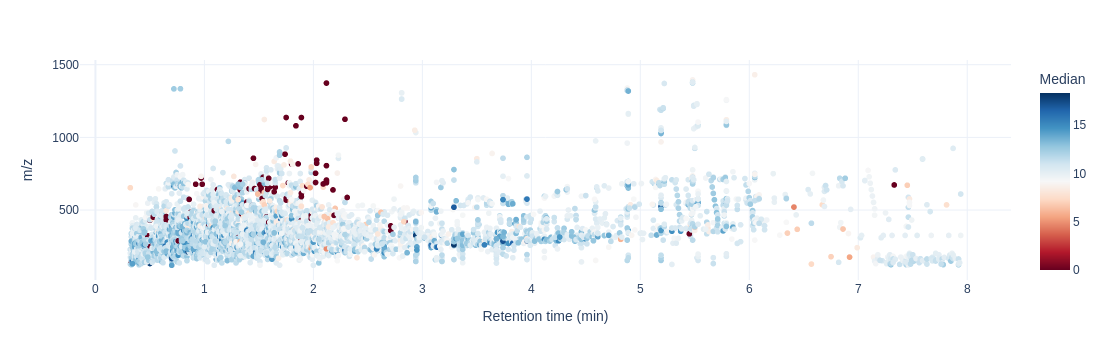

In [6]:
fig = px.scatter(featuresData, x='Rt', y='mz', color='Median',
    render_mode='webgl',
    color_continuous_scale='RdBu',
    labels={'Rt': 'Retention time (min)', 'mz': 'm/z'},
    template='plotly_white')
fig.show()

## PLS-DA model

A PLS-DA model is fit by running a PLS regression on a dummy Y vector encoding class membership.

- **Log transform** (`log(x + 1)`): stabilises variance and handles zeros.
- **UV scaling** (`StandardScaler`): applied inside the pipeline so no single feature dominates.

In [7]:
XDataMatrix = lcMSData.iloc[:, 3:].values
logXDataMatrix = np.log1p(XDataMatrix)

# Encode Condition as a numeric dummy variable: M1=0, PA14=1 (alphabetical order)
YCondition = pds.Categorical(lcMSData['Condition'].values)
YConditionDummy = YCondition.codes

In [8]:
YCondition.categories

Index(['M1', 'PA14'], dtype='object')

In [9]:
YConditionDummy

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1], dtype=int8)

In [10]:
plsModel = Pipeline(steps=[('uv_scale', StandardScaler()), ('PLS', PLSRegression(n_components=2, scale=False))])
plsModel.fit(logXDataMatrix, YConditionDummy)

,steps,"[('uv_scale', ...), ('PLS', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_components,2
,scale,False
,max_iter,500
,tol,1e-06


### PLS-DA model prediction

PLS regression produces continuous predictions. A common simple rule is to threshold at 0.5. Predictions below go to class 0 (M1), above to class 1 (PA14).

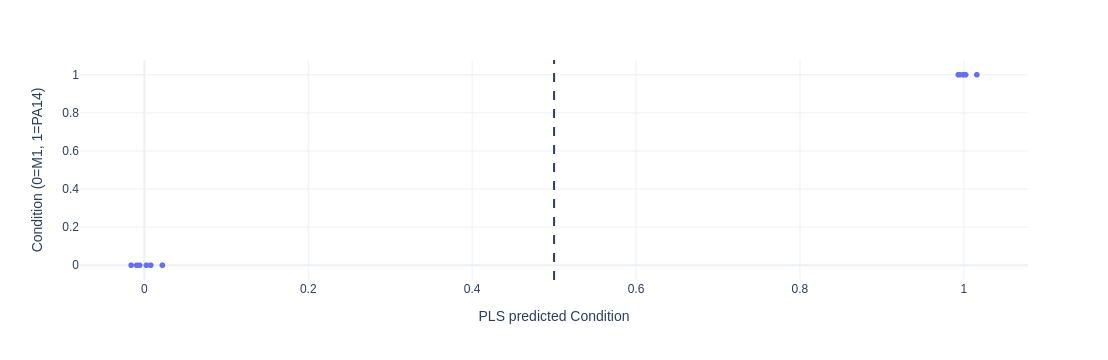

In [11]:
predictFrame = pds.DataFrame(np.c_[plsModel.predict(logXDataMatrix), YConditionDummy],
                             columns=['Predicted', 'Condition'])

fig = px.scatter(predictFrame, x='Predicted', y='Condition', render_mode='webgl',
    labels={'Predicted': 'PLS predicted Condition', 'Condition': 'Condition (0=M1, 1=PA14)'},
    template='plotly_white')
fig.add_vline(x=0.5, line_dash='dash')
fig.show()

Instead of a hard 0.5 threshold we fit a logistic regression on the PLS T-scores and use that as the discriminant step.

'ROC AUC: 1.0'

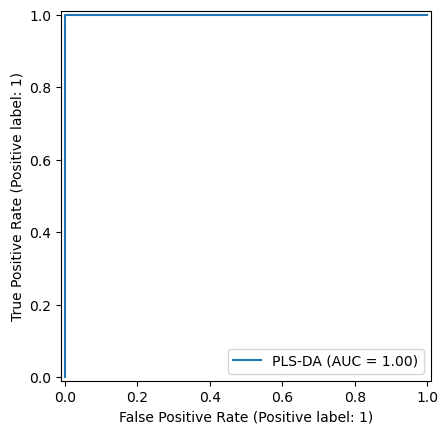

In [12]:
daModel = LogisticRegression()

plsScores = plsModel.transform(X=logXDataMatrix)
daModel.fit(plsScores, YConditionDummy)

plsDaClassification = daModel.predict(plsScores)
plsDaProbas = daModel.predict_proba(plsScores)[:, 1]

RocCurveDisplay.from_estimator(daModel, X=plsScores, y=YConditionDummy, name='PLS-DA')
'ROC AUC: {0}'.format(roc_auc_score(YConditionDummy, plsDaProbas))

With only 12 samples (6 M1 + 6 PA14) and thousands of features, the fitted model will almost always achieve perfect separation. Training-set metrics are not meaningful here - cross-validation and permutation tests below are required.

### PLS-DA scores plot

In [13]:
T_scores = plsModel.transform(logXDataMatrix)

plsResultsDFrame = pds.DataFrame(T_scores, columns=['PLS T' + str(x + 1) for x in range(T_scores.shape[1])])
plsResultsDFrame = pds.concat(
    [lcMSData[['Sample File Name', 'Species', 'Condition']], plsResultsDFrame],
    axis=1)

In [14]:
def hotelling_ellipse(scores, alpha=0.05):
    """Return (x, y) coordinates of the 95% Hotelling T² ellipse for component 1 vs 2."""
    n = scores.shape[0]
    A = 2
    lam = np.var(scores[:, :2], ddof=1, axis=0)
    t2_crit = (A * (n - 1) * (n + 1)) / (n * (n - A)) * f_distribution.ppf(1 - alpha, A, n - A)
    a = np.sqrt(lam[0] * t2_crit)
    b = np.sqrt(lam[1] * t2_crit)
    theta = np.linspace(0, 2 * np.pi, 300)
    return a * np.cos(theta), b * np.sin(theta)

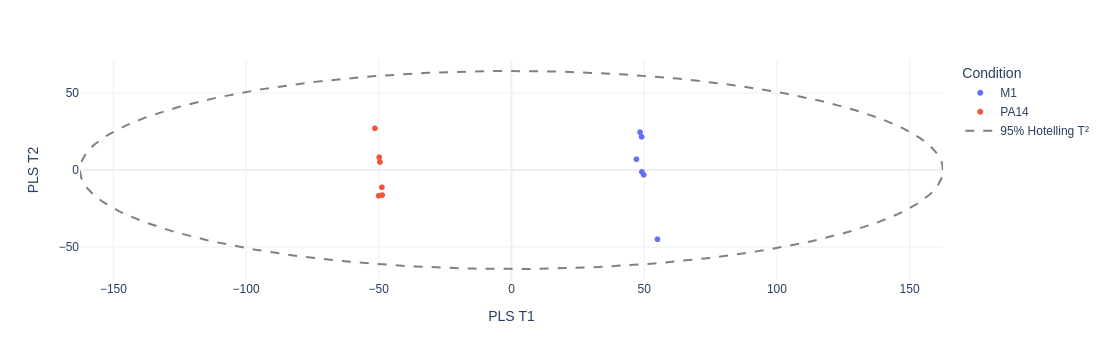

In [15]:
fig = px.scatter(plsResultsDFrame, x='PLS T1', y='PLS T2',
    color='Condition',
    hover_data=['Sample File Name'],
    render_mode='webgl',
    template='plotly_white')

ex, ey = hotelling_ellipse(T_scores)
fig.add_scatter(x=ex, y=ey, mode='lines',
                line=dict(color='grey', dash='dash'),
                name='95% Hotelling T²')
fig.show()

### Weights plot

Features with large positive/negative PLS weights on component 1 drive the separation between M1 and PA14.

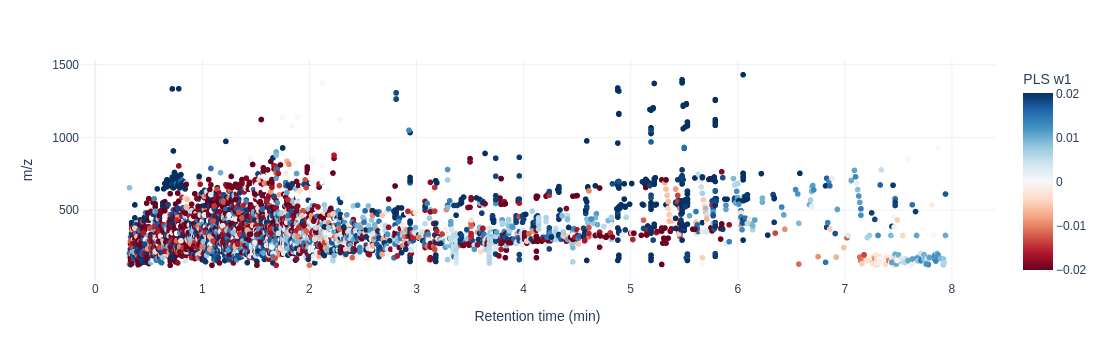

In [16]:
fig = px.scatter(featuresData, x='Rt', y='mz',
    color=plsModel['PLS'].x_weights_[:, 0],
    render_mode='webgl',
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    labels={'Rt': 'Retention time (min)', 'mz': 'm/z', 'color': 'PLS w1'},
    template='plotly_white')
fig.show()

### Model cross-validation

We use stratified K-Fold cross-validation to estimate model performance on samples not used for fitting. With only 12 samples (6 per class), we use **4 folds** of 3 samples each.

In [17]:
def crossValidate_PLSDA(x, y, n_components=2, scale=False, cv=StratifiedKFold(4, shuffle=True, random_state=42)):

    if scale is True:
        plsModel = Pipeline(steps=[('uv_scale', StandardScaler()),
                                   ('PLS', PLSRegression(n_components=n_components, scale=False))])
    else:
        plsModel = Pipeline(steps=[('PLS', PLSRegression(n_components=n_components, scale=False))])

    daModel = LogisticRegression()

    cvResults = {'roc_auc': [], 'f1': [], 'r2': []}

    for trainIdx, testIdx in cv.split(x, y):

        plsModel.fit(x[trainIdx, :], y[trainIdx])

        cvResults['r2'].append(r2_score(y[testIdx], plsModel.predict(x[testIdx, :])))

        plsTrainScores = plsModel.transform(X=x[trainIdx, :])
        daModel.fit(plsTrainScores, y[trainIdx])

        plsTestScores = plsModel.transform(X=x[testIdx, :])
        testPredicted = daModel.predict(plsTestScores)
        testProbas = daModel.predict_proba(plsTestScores)[:, 1]

        cvResults['roc_auc'].append(roc_auc_score(y[testIdx], testProbas))
        cvResults['f1'].append(f1_score(y[testIdx], testPredicted))

    cvResults = {key: np.array(value) for key, value in cvResults.items()}
    return pds.DataFrame(cvResults)

In [18]:
cvResults = crossValidate_PLSDA(logXDataMatrix, YConditionDummy, n_components=2, scale=True,
                                cv=StratifiedKFold(4, shuffle=True, random_state=42))
cvResults

,roc_auc,f1,r2
0,1.0,1.0,0.998925
1,1.0,1.0,0.994372
2,1.0,1.0,0.992091
3,1.0,1.0,0.978473


### Selecting the number of components

We scan over increasing numbers of PLS components and compare cross-validated ROC AUC. With 12 samples and a 4-fold split, the maximum useful number of components is small.

In [19]:
maxNComponents = 6

screePLSDA = [crossValidate_PLSDA(logXDataMatrix, YConditionDummy, n_components=x, scale=True,
                                  cv=StratifiedKFold(4, shuffle=True, random_state=42))
              for x in range(1, maxNComponents + 1)]

In [20]:
cvPLSDA_DFrame = []
for ncomp, cv in enumerate(screePLSDA):
    currentNComp = pds.DataFrame(cv)
    currentNComp['Ncomp'] = ncomp + 1
    cvPLSDA_DFrame.append(currentNComp)
cvPLSDA_DFrame = pds.concat(cvPLSDA_DFrame, axis=0)

In [ ]:
fig = px.box(cvPLSDA_DFrame, x='Ncomp', y='r2',
             labels={'Ncomp': 'Number of components', 'r2': 'Cross-validated R2'},
             template='plotly_white')
fig.show()

In [ ]:
fig = px.box(cvPLSDA_DFrame, x='Ncomp', y='roc_auc',
             labels={'Ncomp': 'Number of components', 'roc_auc': 'ROC AUC'},
             template='plotly_white')
fig.show()

### Fit model with the chosen number of components

A small number of components is usually sufficient - here we pick **2** to visualise a 2-dimensional score plot, but a model with 1 component would work as well.

In [ ]:
plsModel = Pipeline(steps=[('uv_scale', StandardScaler()),
                           ('PLS', PLSRegression(n_components=2, scale=False))])
daModel = LogisticRegression()

plsModel.fit(logXDataMatrix, YConditionDummy)
daModel.fit(plsModel.transform(logXDataMatrix), YConditionDummy)

In [ ]:
cvResults = crossValidate_PLSDA(logXDataMatrix, YConditionDummy, n_components=2, scale=True,
                                cv=StratifiedKFold(4, shuffle=True, random_state=42))
pds.DataFrame(np.c_[cvResults.mean(), cvResults.std()], columns=['Mean', 'Stdev'], index=cvResults.columns)

### Permutation randomisation test

The model is refit many times with a permuted Y to build a null distribution of performance. The empirical p-value is the fraction of permuted models that match or exceed the real model's ROC AUC.

With only 12 samples there are `C(12, 6) = 924` unique Y permutations, so the p-value resolution is limited.

In [ ]:
nPermutations = 1000

np.random.seed(42)
permResults = []

for permutation in range(nPermutations):
    permutedY = np.random.permutation(YConditionDummy)
    permcvResults = crossValidate_PLSDA(logXDataMatrix, permutedY, n_components=2, scale=False,
                                        cv=StratifiedKFold(4, shuffle=True))
    permResults.append(permcvResults.mean())

permResults = pds.DataFrame(permResults)

In [ ]:
fig = px.histogram(permResults, x='roc_auc', nbins=20)
fig.add_vline(x=cvResults['roc_auc'].mean(), line_dash='dash')
fig.show()
'Permutation p-value ~ {0}'.format(np.sum(permResults['roc_auc'] >= cvResults['roc_auc'].mean()) / (nPermutations + 1))

## Three-class example: M1 vs PA14 vs media

So far the PLS-DA model has discriminated two classes. PLS-DA generalises to more than two by using a **one-hot encoded Y matrix** — one column per class, and a multiclass classifier using the PLS scores. Here we add the blank media samples back in and fit a 3-class model (M1, PA14, media); QC injections are still excluded as they are not a biological class.

In [ ]:
# Reload the full dataset (lcMSData was filtered and PQN-normalised in place above)
lcMSData_3c = pds.read_csv('./Data/PA_microbial_dataset.csv')

# Keep M1, PA14 and media (drop QC)
mask_3c = lcMSData_3c['Condition'].isin(['M1', 'PA14', 'media'])
lcMSData_3c = lcMSData_3c[mask_3c].reset_index(drop=True)

# PQN normalise (same procedure as before)
X_3c_raw = lcMSData_3c[intensity_cols].values.astype(float)
ref_3c = np.median(X_3c_raw, axis=0)
q_3c = np.where((ref_3c > 0) & (X_3c_raw > 0), X_3c_raw / np.where(ref_3c > 0, ref_3c, 1), np.nan)
sf_3c = np.nanmedian(q_3c, axis=1)
lcMSData_3c[intensity_cols] = X_3c_raw / sf_3c[:, None]

print(lcMSData_3c['Condition'].value_counts().to_string())

In [ ]:
X_3c = lcMSData_3c.iloc[:, 3:].values
logX_3c = np.log1p(X_3c)

# One-hot encode Y: one column per class, values 0/1
YCondition_3c = pds.Categorical(lcMSData_3c['Condition'].values,
                                categories=['M1', 'PA14', 'media'])
YDummy_3c = pds.get_dummies(YCondition_3c).values.astype(float)
yLabel_3c = YCondition_3c.codes  # integer labels for the classifier / metrics

print('Classes:', list(YCondition_3c.categories))
print('Y dummy shape:', YDummy_3c.shape)

In [ ]:
plsModel_3c = Pipeline(steps=[('uv_scale', StandardScaler()),
                              ('PLS', PLSRegression(n_components=2, scale=False))])
plsModel_3c.fit(logX_3c, YDummy_3c)

T_scores_3c = plsModel_3c.transform(logX_3c)

### Scores plot (3-class)

In [ ]:
plsResultsDFrame_3c = pds.DataFrame(T_scores_3c, columns=['PLS T1', 'PLS T2'])
plsResultsDFrame_3c = pds.concat(
    [lcMSData_3c[['Sample File Name', 'Species', 'Condition']], plsResultsDFrame_3c],
    axis=1)

fig = px.scatter(plsResultsDFrame_3c, x='PLS T1', y='PLS T2',
    color='Condition',
    hover_data=['Sample File Name'],
    render_mode='webgl',
    template='plotly_white')

ex, ey = hotelling_ellipse(T_scores_3c)
fig.add_scatter(x=ex, y=ey, mode='lines',
                line=dict(color='grey', dash='dash'),
                name='95% Hotelling T²')
fig.show()

### Multiclass discriminant step

A multinomial logistic regression on the PLS scores assigns a class probability to each sample. The class with the highest probability is the predicted class.

In [ ]:
daModel_3c = LogisticRegression(max_iter=1000)
daModel_3c.fit(T_scores_3c, yLabel_3c)

pred_3c = daModel_3c.predict(T_scores_3c)
proba_3c = daModel_3c.predict_proba(T_scores_3c)

print('Training confusion (rows = true, cols = predicted):')
print(pds.crosstab(
    pds.Categorical.from_codes(yLabel_3c, categories=YCondition_3c.categories),
    pds.Categorical.from_codes(pred_3c, categories=YCondition_3c.categories),
    rownames=['true'], colnames=['pred']))

print('\nTraining macro ROC AUC (one-vs-rest): {:.3f}'.format(
    roc_auc_score(yLabel_3c, proba_3c, multi_class='ovr', average='macro')))
print('Training macro F1:                     {:.3f}'.format(
    f1_score(yLabel_3c, pred_3c, average='macro')))

### Per-class ROC curves

The macro ROC AUC reported above collapses three one-vs-rest comparisons into a single number. To see how each class is separated from the rest, we plot the three one-vs-rest ROC curves on a single axes. With only 17 samples (and using the training-set probabilities) these curves are optimistic — for an honest estimate, see the cross-validated ROC AUC in the next section.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))

for k, className in enumerate(YCondition_3c.categories):
    yTrueBinary = (yLabel_3c == k).astype(int)
    RocCurveDisplay.from_predictions(
        yTrueBinary,
        proba_3c[:, k],
        name=f'{className} vs rest',
        ax=ax,
    )

ax.plot([0, 1], [0, 1], linestyle='--', color='grey', linewidth=1)
ax.set_title('Per-class ROC (one-vs-rest, training set)')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.legend(loc='lower right')
plt.show()

### Cross-validation (3-class)

The same train/test split logic applies, but with macro-averaged multiclass metrics.

In [ ]:
def crossValidate_PLSDA_multiclass(x, y_dummy, y_label, n_components=2,
                                   cv=StratifiedKFold(4, shuffle=True, random_state=42)):
    plsModel = Pipeline(steps=[('uv_scale', StandardScaler()),
                               ('PLS', PLSRegression(n_components=n_components, scale=False))])
    daModel = LogisticRegression(max_iter=1000)

    cvResults = {'roc_auc_ovr': [], 'f1_macro': []}

    for trainIdx, testIdx in cv.split(x, y_label):
        plsModel.fit(x[trainIdx, :], y_dummy[trainIdx, :])
        plsTrainScores = plsModel.transform(X=x[trainIdx, :])
        daModel.fit(plsTrainScores, y_label[trainIdx])

        plsTestScores = plsModel.transform(X=x[testIdx, :])
        testPred = daModel.predict(plsTestScores)
        testProba = daModel.predict_proba(plsTestScores)

        # labels= ensures ROC AUC is computed over all 3 classes even if a fold is missing one
        cvResults['roc_auc_ovr'].append(
            roc_auc_score(y_label[testIdx], testProba,
                          multi_class='ovr', average='macro', labels=[0, 1, 2]))
        cvResults['f1_macro'].append(
            f1_score(y_label[testIdx], testPred, average='macro', labels=[0, 1, 2]))

    return pds.DataFrame({k: np.array(v) for k, v in cvResults.items()})

cvResults_3c = crossValidate_PLSDA_multiclass(logX_3c, YDummy_3c, yLabel_3c, n_components=2,
                                              cv=StratifiedKFold(4, shuffle=True, random_state=42))
cvResults_3c

In [ ]:
pds.DataFrame(np.c_[cvResults_3c.mean(), cvResults_3c.std()],
              columns=['Mean', 'Stdev'], index=cvResults_3c.columns)

### Interpreting components in a multiclass PLS-DA

With a single binary Y, each PLS component has a clean interpretation: one direction in feature space that maximises covariance with the class indicator, and one set of weights/loadings that tells you which features drive that direction.

With a **one-hot Y matrix** (3 columns here), the picture changes:

- **Scores (`T`)** still place each sample at a point in PLS space. Samples that land close together have similar metabolic profiles along those components, and each class occupies a region determined by its cloud of points.
- **X-loadings (`p` — `plsModel['PLS'].x_loadings_`)** are the **counterpart of the scores plot** and the most important object to interpret alongside it. For component *a*, `X ≈ T_a · p_aᵀ`, so a feature with a large positive `p_a` is one whose intensity is *high* in samples with positive scores on component *a*, and low in samples with negative scores. **Always read loadings paired with scores:** pick a direction in the scores plot (e.g. where media samples land), then look at which features load in that same direction.
- **X-weights (`w*` — `plsModel['PLS'].x_weights_`)** define the same component directions but in "how to build the scores from X" form (`T = X · w*`). `w*` and `p` are highly correlated and usually tell the same story; `p` is generally preferred for interpretation because of the direct score-loading relationship above.
- Both `w*` and `p` are **shared across all classes**. A single component is a compromise direction that explains variance in *all* dummy columns at once. So component 1 is not "the M1 axis" — it is whichever direction best serves M1, PA14 *and* media jointly. Use the Y-weights to tell which class each component mainly serves. 
- **Y-weights (`q` — `plsModel['PLS'].y_weights_`)** have shape `(n_classes, n_components)` and tell you **how each class projects onto each component**. This is the bridge: cross-reference a class's row in `q` with the loadings `p` for that component to decide whether large-loading features are elevated in that class or the opposite.
- **Regression coefficients (`B` — `plsModel['PLS'].coef_`)** have shape `(n_classes, n_features)` and collapse the multi-component model into a **direct per-class feature weighting**. `B[class, :]` is the feature vector that best predicts the dummy for that class from X — the cleanest object when you want to answer "which features are characteristic of class *k*?".

Rules of thumb:
- **Scores and loadings are a pair.** A feature's sign and magnitude in `p_a` directly matches how samples along component *a* differ; this is the PLS-DA biplot logic.
- **Do not read a single `w*` or `p` column as class-specific** in multiclass PLS-DA. Use score plots to understand which components separate classes from each other, `q` to relate each components to class prediction,  or `B` for per-class feature rankings.
- Use `w*` / `p` to understand the *axes* of the scores plot, and `B` to understand *what separates a specific class from the rest*.

In [ ]:
w = plsModel_3c['PLS'].x_weights_       # shape (n_features, n_components) - shared across classes
p = plsModel_3c['PLS'].x_loadings_      # shape (n_features, n_components) - shared; paired with scores
q = plsModel_3c['PLS'].y_weights_       # shape (n_classes,  n_components) - class-to-component projection
B = plsModel_3c['PLS'].coef_            # shape (n_classes,  n_features)   - per-class feature coefficients

print('x_weights_  shape:', w.shape)
print('x_loadings_ shape:', p.shape)
print('y_weights_  shape:', q.shape)
print('coef_       shape:', B.shape)

# Y-weights matrix: read rows as "how class k loads on component a"
pds.DataFrame(q,  index=YCondition_3c.categories,
              columns=['T' + str(i + 1) for i in range(q.shape[1])])

**Component axes (shared).** The two panels below plot `w1` and `w2` on the feature map. These are the axes of the PLS-DA scores plot — they describe the *directions in feature space* that the model has built, not the individual classes.

In [ ]:
for i in range(w.shape[1]):
    fig = px.scatter(featuresData, x='Rt', y='mz',
        color=w[:, i],
        render_mode='webgl',
        color_continuous_scale='RdBu',
        color_continuous_midpoint=0,
        labels={'Rt': 'Retention time (min)', 'mz': 'm/z',
                'color': 'w' + str(i + 1)},
        title='PLS-DA X-weights — component ' + str(i + 1),
        template='plotly_white')
    fig.show()

**Loadings paired with the scores plot.** These are the objects to compare side-by-side with the scores plot. A feature with large positive `p_a` is elevated in samples that sit on the positive side of component *a* in the scores plot, and depleted in samples on the negative side. This is the biplot interpretation.

In [ ]:
for i in range(p.shape[1]):
    fig = px.scatter(featuresData, x='Rt', y='mz',
        color=p[:, i],
        render_mode='webgl',
        color_continuous_scale='RdBu',
        color_continuous_midpoint=0,
        labels={'Rt': 'Retention time (min)', 'mz': 'm/z',
                'color': 'p' + str(i + 1)},
        title='PLS-DA X-loadings — component ' + str(i + 1),
        template='plotly_white')
    fig.show()

**Per-class feature importance.** The rows of `coef_` give, for each class, the feature vector that best predicts "is this sample in class *k*?". Red = feature is **elevated** in the class relative to the rest; blue = **depleted**. Read these plots directly for biological interpretation per class.

In [ ]:
for k, class_name in enumerate(YCondition_3c.categories):
    fig = px.scatter(featuresData, x='Rt', y='mz',
        color=B[k, :],
        render_mode='webgl',
        color_continuous_scale='RdBu',
        color_continuous_midpoint=0,
        labels={'Rt': 'Retention time (min)', 'mz': 'm/z',
                'color': 'B[' + class_name + ']'},
        title='Regression coefficients — ' + class_name + ' vs rest',
        template='plotly_white')
    fig.show()